<h2><b>Household Energy Time Series Forcasting </b></h2>
This project Forcast household energy consumption from time series, visualizing patterns 
and to build a production ready model.

Tools: Python(Pandas, NumPy, Matplotlib, Seaborn, Scilit-learn, XGBoost)

In [278]:
# Data handling
import pandas as pd
import numpy as np

# Date/time features
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To suppress warnings (optional)
import warnings
warnings.filterwarnings('ignore')

In [279]:
# Load dataset

import zipfile
import pandas as pd

zip_path = 'archieve.zip'
inner_file = 'household_power_consumption.txt'  # name of the text file inside zip

with zipfile.ZipFile(zip_path) as z:
    with z.open(inner_file) as f:
        df = pd.read_csv(f, sep=';', parse_dates={'DateTime': ['Date', 'Time']}, na_values='?', low_memory=False)
        
print(df.head(5))

             DateTime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  


In [281]:
import pandas as pd

# Step 1: Ensure datetime index
if not isinstance(df.index, pd.DatetimeIndex):
    # Find first datetime-like column
    datetime_col = None
    for col in df.columns:
        try:
            pd.to_datetime(df[col].iloc[0])
            datetime_col = col
            break
        except Exception:
            continue
    if datetime_col is None:
        raise ValueError("No datetime-like column found in dataframe.")
    df[datetime_col] = pd.to_datetime(df[datetime_col], errors='raise')
    df = df.set_index(datetime_col)
else:
    df.index = pd.to_datetime(df.index, errors='raise')

# Step 2: Convert mins to hour
df_hourly = df.resample('H').mean()

<h2><b>Exploratory Data Analysis (EDA) Visualizations </b></h2>

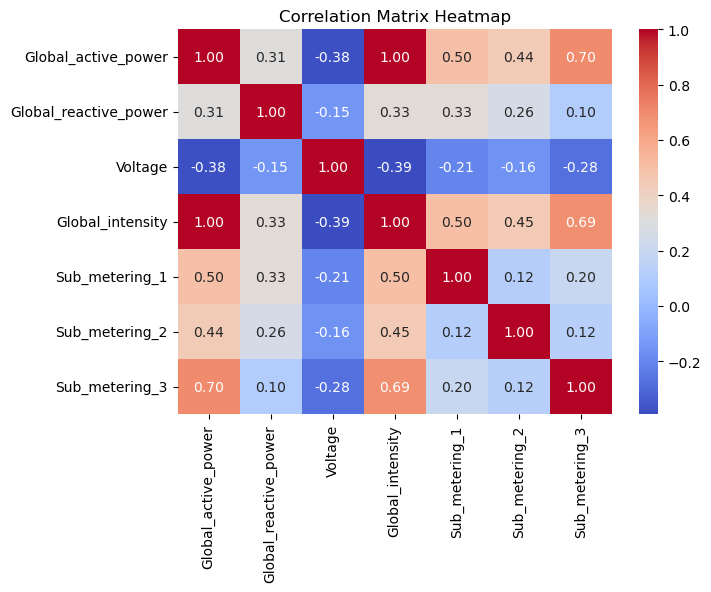

In [7]:
# Correlation matrix

# Select numeric columns
numeric_cols = df_hourly.select_dtypes(include='number').columns

# Compute correlation matrix
corr_matrix = df_hourly[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

---
**Note:** Original data in kW has been converted to kWh per hour.  
1 kWh ≈ 1 unit of electricity ⚡ 
---

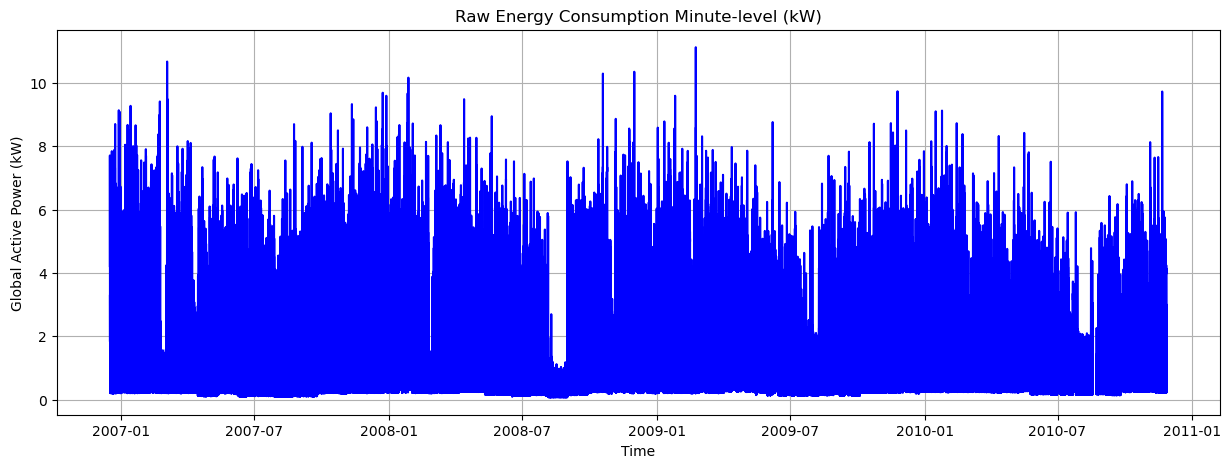

Minimum consumption = 0.0760 kW at 2008-08-12 19:26:00
Maximum consumption = 11.1220 kW at 2009-02-22 17:09:00
Mean consumption = 1.0916 kW


In [249]:
# Raw minute (kW) Consumption from Global_active_power (kW)

plt.figure(figsize=(15,5))
plt.plot(df.index, df['Global_active_power'], color='blue')
plt.title("Raw Energy Consumption Minute-level (kW)")
plt.xlabel("Time"); plt.ylabel("Global Active Power (kW)"); plt.grid(True); plt.show()
min_val, max_val, avg_val = df['Global_active_power'].min(), df['Global_active_power'].max(), df['Global_active_power'].mean()
min_time, max_time = df['Global_active_power'].idxmin(), df['Global_active_power'].idxmax()

print(f"Minimum consumption = {min_val:.4f} kW at {min_time}")
print(f"Maximum consumption = {max_val:.4f} kW at {max_time}")
print(f"Mean consumption = {avg_val:.4f} kW")

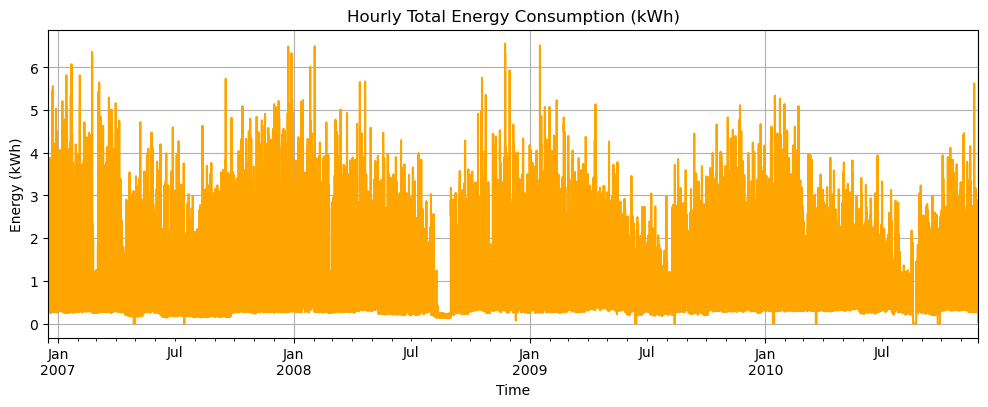

Hourly Min = 0.0000 kWh (0.0 kW) at 2007-04-28 01:00:00
Hourly Max = 6.5605 kWh (393.6 kW) at 2008-11-23 18:00:00
Hourly Average (Mean) = 1.0779 kWh (64.7 kW)


In [46]:
# Minute → kWh, resample hourly, plot, print min/max

df_hourly_kwh = (df['Global_active_power']/60).resample('H').sum()

df_hourly_kwh.plot(figsize=(12,4), color='orange', title="Hourly Total Energy Consumption (kWh)")
plt.xlabel("Time"); plt.ylabel("Energy (kWh)"); plt.grid(True); plt.show()
hr_min, hr_max, hr_avg = df_hourly_kwh.min(), df_hourly_kwh.max(), df_hourly_kwh.mean()

print(f"Hourly Min = {hr_min:.4f} kWh ({hr_min*60:.1f} kW) at {df_hourly_kwh.idxmin()}")
print(f"Hourly Max = {hr_max:.4f} kWh ({hr_max*60:.1f} kW) at {df_hourly_kwh.idxmax()}")
print(f"Hourly Average (Mean) = {hr_avg:.4f} kWh ({hr_avg*60:.1f} kW)")

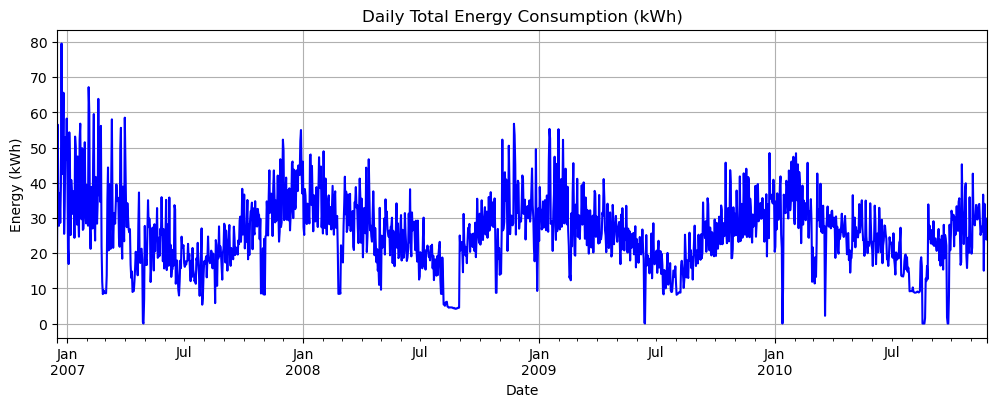

Daily Min = 0.0000 kWh (0.0 kW) at 2007-04-29 00:00:00
Daily Max = 79.5564 kWh (4773.4 kW) at 2006-12-23 00:00:00
Daily Average (Mean) = 25.8556 kWh (1551.3 kW)


In [44]:
# Daily power consumption

df_daily_kwh = (df['Global_active_power']/60).resample('D').sum()

df_daily_kwh.plot(figsize=(12,4), color='blue', title="Daily Total Energy Consumption (kWh)")
plt.xlabel("Date"); plt.ylabel("Energy (kWh)"); plt.grid(True); plt.show()
day_min, day_max, day_avg = df_daily_kwh.min(), df_daily_kwh.max(), df_daily_kwh.mean()

print(f"Daily Min = {day_min:.4f} kWh ({day_min*60:.1f} kW) at {df_daily_kwh.idxmin()}")
print(f"Daily Max = {day_max:.4f} kWh ({day_max*60:.1f} kW) at {df_daily_kwh.idxmax()}") 
print(f"Daily Average (Mean) = {day_avg:.4f} kWh ({day_avg*60:.1f} kW)")

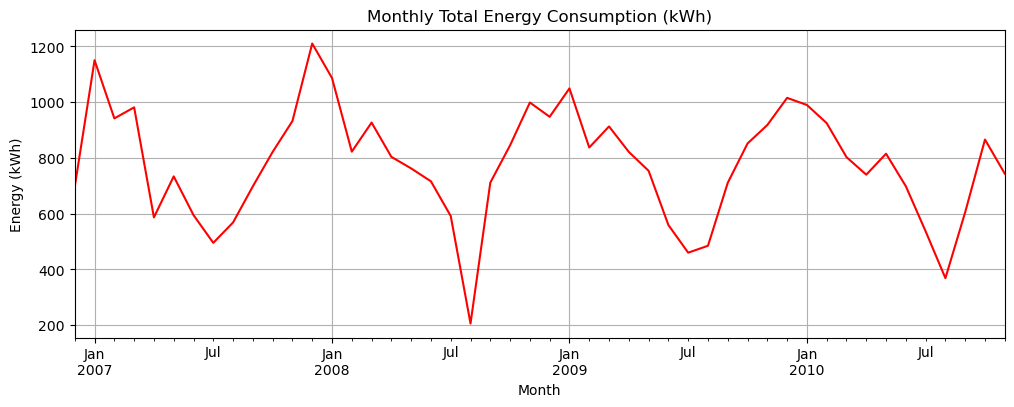

Monthly Min = 205.6980 kWh (12341.9 kW) at 2008-08-31 00:00:00
Monthly Max = 1210.0695 kWh (72604.2 kW) at 2007-12-31 00:00:00
Monthly Average (Mean) = 776.7447 kWh (46604.7 kW)


In [48]:
# Monthly power consumption

df_monthly_kwh = (df['Global_active_power']/60).resample('M').sum()

df_monthly_kwh.plot(figsize=(12,4), color='red', title="Monthly Total Energy Consumption (kWh)")
plt.xlabel("Month"); plt.ylabel("Energy (kWh)"); plt.grid(True); plt.show()
mon_min, mon_max, mon_avg = df_monthly_kwh.min(), df_monthly_kwh.max(), df_monthly_kwh.mean()

print(f"Monthly Min = {mon_min:.4f} kWh ({mon_min*60:.1f} kW) at {df_monthly_kwh.idxmin()}")
print(f"Monthly Max = {mon_max:.4f} kWh ({mon_max*60:.1f} kW) at {df_monthly_kwh.idxmax()}")
print(f"Monthly Average (Mean) = {mon_avg:.4f} kWh ({mon_avg*60:.1f} kW)")


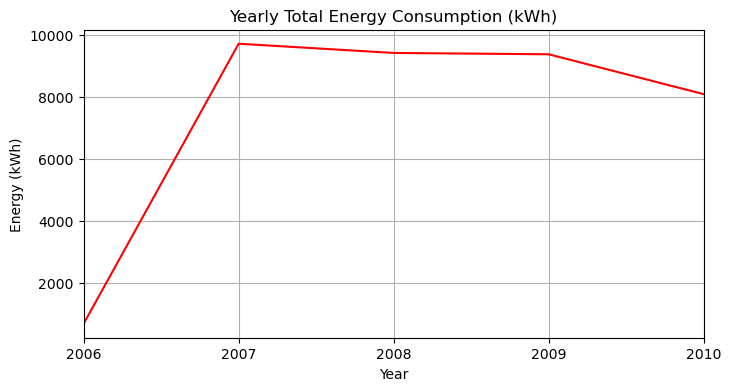

Min Year = 696.8880 kWh (41813.3 kW) at 2006-12-31 00:00:00
Max Year = 9711.8031 kWh (582708.2 kW) at 2007-12-31 00:00:00


In [62]:
# Yearly power consumption

df_yearly_kwh = (df['Global_active_power']/60).resample('Y').sum()

df_yearly_kwh.plot(figsize=(8,4), color='red', title="Yearly Total Energy Consumption (kWh)")
plt.xlabel("Year"); plt.ylabel("Energy (kWh)"); plt.grid(True); plt.show()
yr_min, yr_max, yr_avg = df_yearly_kwh.min(), df_yearly_kwh.max(), df_yearly_kwh.mean() 

print(f"Min Year = {yr_min:.4f} kWh ({yr_min*60:.1f} kW) at {df_yearly_kwh.idxmin()}")
print(f"Max Year = {yr_max:.4f} kWh ({yr_max*60:.1f} kW) at {df_yearly_kwh.idxmax()}")

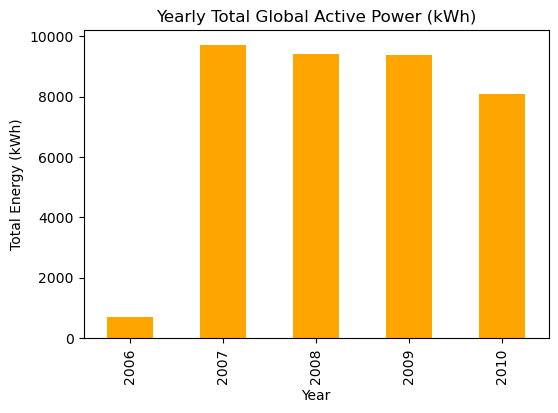

2006: 697 kWh (41813 kW)
2007: 9712 kWh (582708 kW)
2008: 9415 kWh (564893 kW)
2009: 9372 kWh (562315 kW)
2010: 8088 kWh (485295 kW)

TOTAL (All Years): 37284 kWh (2237025 kW)


In [70]:
# Total Yearly power consumption

yearly_total_kwh = df['Global_active_power'].resample('Y').sum()/60
yearly_total_kwh.index = yearly_total_kwh.index.year

yearly_total_kwh.plot(kind='bar', color='orange', figsize=(6,4))
plt.title("Yearly Total Global Active Power (kWh)"); plt.ylabel("Total Energy (kWh)"); plt.xlabel("Year"); plt.show()

for y, kwh in yearly_total_kwh.items(): print(f"{y}: {kwh:.0f} kWh ({kwh*60:.0f} kW)")
print(f"\nTOTAL (All Years): {yearly_total_kwh.sum():.0f} kWh ({yearly_total_kwh.sum()*60:.0f} kW)")

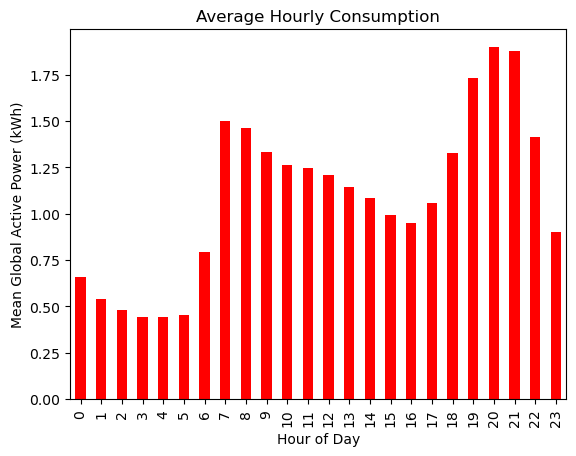

In [244]:
# Average power consumption per hour

df_hourly.groupby(df_hourly.index.hour)['Global_active_power'].mean().plot(kind='bar', color='red')
plt.xlabel("Hour of Day"); plt.ylabel("Mean Global Active Power (kWh)")
plt.title("Average Hourly Consumption"); plt.show()

In [ ]:
Shows low consumption during early hours (0-5) and high consumption in evening hours (19-22)

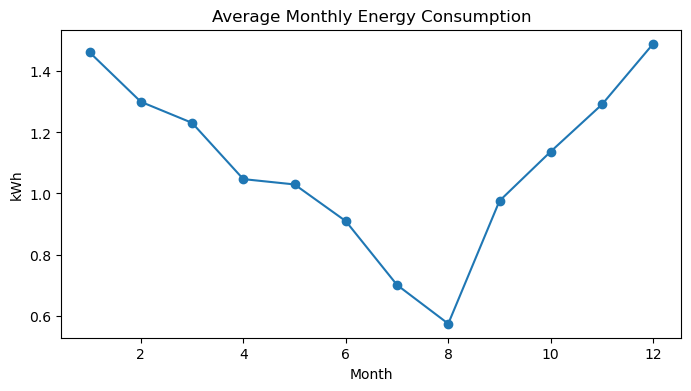

In [267]:
monthly = df_hourly.groupby(df_hourly.index.month)['Global_active_power'].mean()

plt.figure(figsize=(8,4))
plt.plot(monthly, marker='o')
plt.title('Average Monthly Energy Consumption')
plt.xlabel('Month')
plt.ylabel('kWh')
plt.show()

In [ ]:
-Average monthly energy consumption over four years shows lowest demand in July and August, summer period.
-Highest energy consumption period in January and December, winter period.

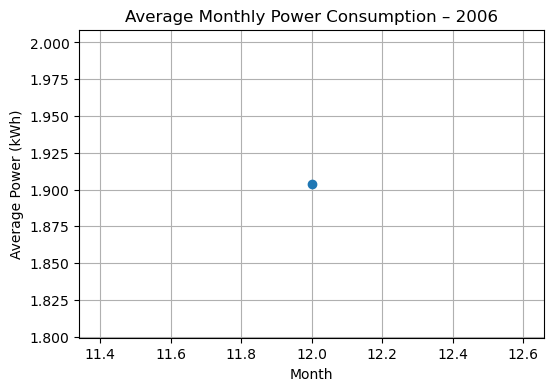

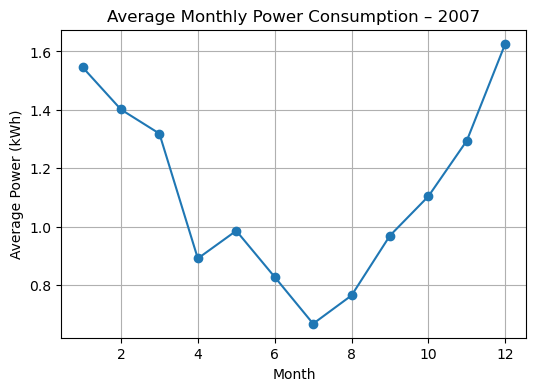

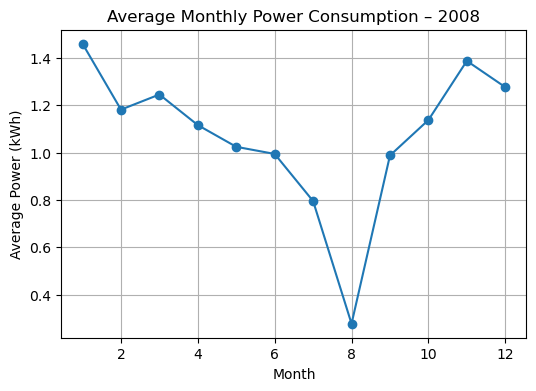

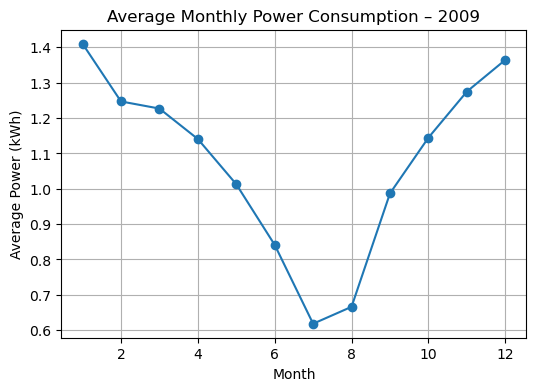

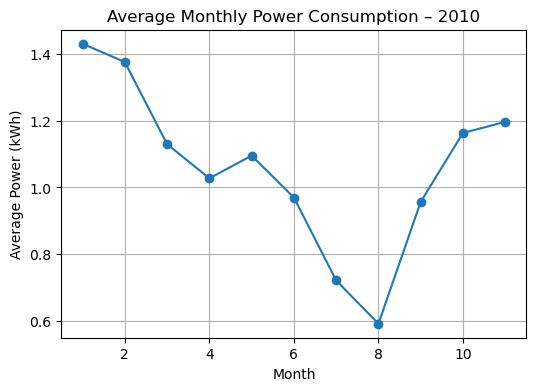

In [292]:
# Average monthly consumption from 2006-2010

for year, g in df_hourly.groupby(df_hourly.index.year):
    monthly_avg = g.groupby(g.index.month)['Global_active_power'].mean()
    
    plt.figure(figsize=(6,4))
    monthly_avg.plot(marker='o')
    plt.title(f'Average Monthly Power Consumption – {year}')
    plt.xlabel('Month')
    plt.ylabel('Average Power (kWh)')
    plt.grid(True)
    plt.show()

<h2><b>Feature Engineering </b></h2>

In [322]:
import numpy as np
import pandas as pd

df_hourly = df_hourly.copy()

target = 'Global_active_power'

# Raw time features (interpretable)
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['is_weekend'] = df_hourly['day_of_week'].isin([5, 6]).astype(int)
df_hourly['week'] = df_hourly.index.isocalendar().week
df_hourly['day_of_year'] = df_hourly.index.day_of_year
df_hourly['month'] = df_hourly.index.month
df_hourly['quarter'] = df_hourly.index.quarter
df_hourly['year'] = df_hourly.index.year

# CORE FEATURE SET (baseline)
x_col = [
    # Raw measurements
    'Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',

    # Time sequence (fine to coarse)
    'hour', 'day_of_week', 'is_weekend', 'week', 'day_of_year', 'month', 'quarter', 'year',
]

y_col = target

In [323]:
# Spliting Train-Test before time-based features to avoid data leakage

n = len(df_hourly)

train_end = int(n * 0.8)

df_train = df_hourly.iloc[:train_end]
df_test  = df_hourly.iloc[train_end:]

In [8]:
df_train.shape, df_test.shape

((27671, 15), (6918, 15))

In [328]:
# Training lags + rolling mean

for df_ in [df_train, df_test]:
    # Create lags
    df_['lag_1'] = df_['Global_active_power'].shift(1)
    df_['lag_24'] = df_['Global_active_power'].shift(24)
    
    # Create rolling mean (past 3 hours, example)
    df_['rolling_mean_3'] = df_['Global_active_power'].shift(1).rolling(window=3).mean()
    df_['rolling_std_3'] = df_['Global_active_power'].shift(1).rolling(window=3).std()
    
    # Drop rows with any NaN in the split (caused by shift/rolling)
    df_.dropna(inplace=True) 

# Final feature list including lags and rolling mean
x_col_lags = x_col + ['lag_1', 'lag_24', 'rolling_mean_3', 'rolling_std_3']

In [329]:
# Encode cyclic features (e.g: hour/day/week), sine/cosine to preserve cyclical pattern

class CyclicalFeatures:
    def transform(self, X):
        X = X.copy()

        X['sin_hour']     = np.sin(2*np.pi*X['hour'] / 24)
        X['cos_hour']     = np.cos(2*np.pi*X['hour'] / 24)

        X['sin_dow']      = np.sin(2*np.pi*X['day_of_week'] / 7)
        X['cos_dow']      = np.cos(2*np.pi*X['day_of_week'] / 7)

        X['sin_month']    = np.sin(2*np.pi*X['month'] / 12)
        X['cos_month']    = np.cos(2*np.pi*X['month'] / 12)

        X['sin_quarter']  = np.sin(2*np.pi*X['quarter'] / 4)
        X['cos_quarter']  = np.cos(2*np.pi*X['quarter'] / 4)

        X['sin_doy']      = np.sin(2*np.pi*X['day_of_year'] / 365.25)
        X['cos_doy']      = np.cos(2*np.pi*X['day_of_year'] / 365.25)

        return X

In [326]:
cycler = CyclicalFeatures()

x_cols = lambda df: cycler.transform(df[x_col_lags])

X_train = x_cols(df_train)
y_train = df_train[y_col]

X_test = x_cols(df_test)
y_test = df_test[y_col]

In [18]:
print("Train NaNs:", df_train.isnull().sum().sum())
print("Test  NaNs:", df_test.isnull().sum().sum())

Train NaNs: 0
Test  NaNs: 0


In [330]:
# Minimal shape check
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (27372, 27), y_train: (27372,)
X_test:  (6583, 27), y_test:  (6583,)


In [19]:
# Hyperparameter tuning with optuna to optimize time series model performance

import optuna
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

# Use your prepared training data
X_train_full = X_train
y_train_full = y_train

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),  
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 4),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 6),
        'random_state': 42,
        'n_jobs': -1
    }

    rmse_folds = []

    for train_idx, val_idx in tscv.split(X_train_full):
        X_tr = X_train_full.iloc[train_idx]
        y_tr = y_train_full.iloc[train_idx]
        X_vl = X_train_full.iloc[val_idx]
        y_vl = y_train_full.iloc[val_idx]

        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr, verbose=0)  

        y_pred = model.predict(X_vl)
        rmse_folds.append(np.sqrt(mean_squared_error(y_vl, y_pred)))

    return np.mean(rmse_folds)

# Run Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)  

print("Best parameters:", study.best_trial.params)
print("Best RMSE:", study.best_value)

[I 2026-01-23 21:46:47,361] A new study created in memory with name: no-name-5f7d397e-8a2f-438e-b340-aa04d677a024
[I 2026-01-23 21:47:35,782] Trial 0 finished with value: 0.2896427803125382 and parameters: {'n_estimators': 2467, 'max_depth': 5, 'learning_rate': 0.031080842458154526, 'subsample': 0.84466319935139, 'colsample_bytree': 0.7563368881175087, 'reg_alpha': 3.7378218978624287, 'reg_lambda': 4.423856932422162}. Best is trial 0 with value: 0.2896427803125382.
[I 2026-01-23 21:47:42,179] Trial 1 finished with value: 0.29469122929515634 and parameters: {'n_estimators': 548, 'max_depth': 4, 'learning_rate': 0.05025940606721932, 'subsample': 0.906715209282683, 'colsample_bytree': 0.8946231471462287, 'reg_alpha': 0.6456193094753853, 'reg_lambda': 3.276941385626021}. Best is trial 0 with value: 0.2896427803125382.
[I 2026-01-23 21:48:03,946] Trial 2 finished with value: 0.3187128602431308 and parameters: {'n_estimators': 1679, 'max_depth': 3, 'learning_rate': 0.19505198659308629, 'subs

Best parameters: {'n_estimators': 1743, 'max_depth': 5, 'learning_rate': 0.014288187058168636, 'subsample': 0.7754386743411238, 'colsample_bytree': 0.8677842319085053, 'reg_alpha': 3.7980312982407947, 'reg_lambda': 2.8152992415085762}
Best RMSE: 0.28563224581371255


In [ ]:
from xgboost import XGBRegressor
import numpy as np

# Step 1: Copy hyperparameters (from previous tuning)
best_params = {
    'n_estimators': 1743,
    'max_depth': 5,
    'learning_rate': 0.014288187058168636,
    'subsample': 0.7754386743411238,
    'colsample_bytree': 0.8677842319085053,
    'reg_alpha': 3.7980312982407947, 
    'reg_lambda': 2.8152992415085762,
    'random_state': 42,
    'n_jobs': -1
}

# Step 2: Assign Training
X_train_final = X_train
y_train_final = y_train

# Step 3: Train
final_model = XGBRegressor(**best_params)
final_model.fit(X_train_final, y_train_final)

In [251]:
# Evaluate on test set

from sklearn.metrics import mean_squared_error

y_test_pred = final_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f'Test RMSE: {test_rmse:.4f} kWh')

Test RMSE: 0.2259 kWh


In [288]:
# Save trained model
import joblib; joblib.dump(final_model, 'energy_model_xgb.pkl') 

['energy_model_xgb.pkl']

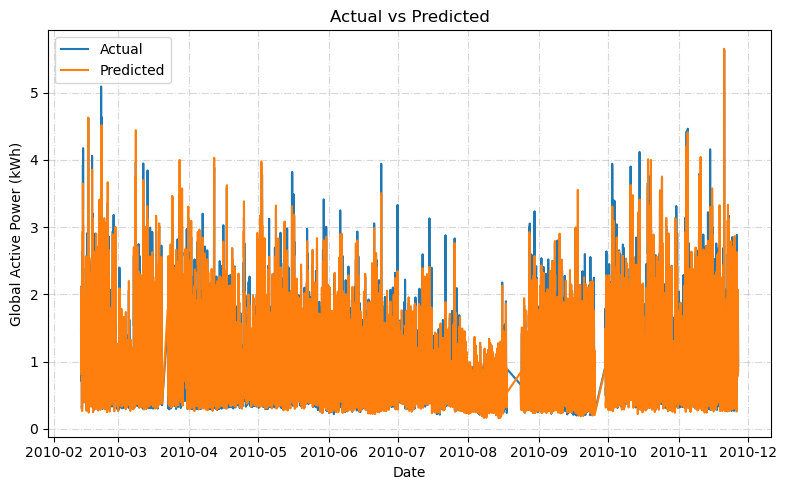

In [337]:
# Test set for Actual and Predicted Global Active Power

plt.figure(figsize=(8,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_test_pred, label='Predicted')
plt.xlabel('Date'); plt.ylabel('Global Active Power (kWh)')
plt.title('Actual vs Predicted')
plt.legend(); plt.grid(True, linestyle='-.', alpha=0.5)
plt.tight_layout(); plt.show()

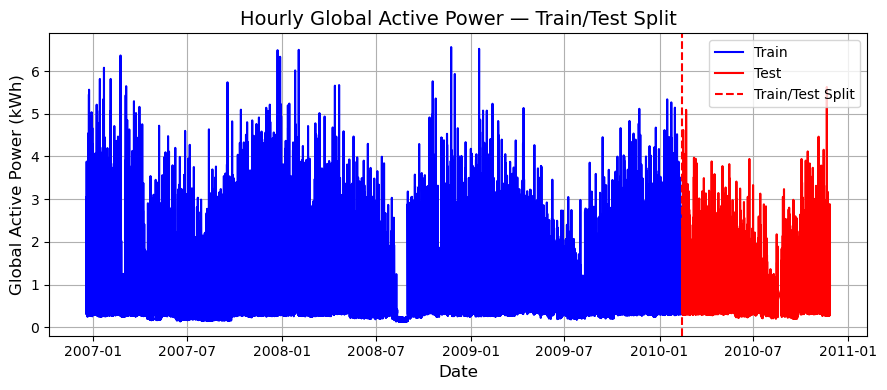

In [318]:
# Training and Test set splittling

plt.figure(figsize=(9,4))
plt.plot(df_train.index, df_train['Global_active_power'], label='Train', color='blue')
plt.plot(df_test.index,  df_test['Global_active_power'],  label='Test', color='red')
plt.axvline(df_test.index.min(), color='red', linestyle='--', label='Train/Test Split')

plt.ylabel('Global Active Power (kWh)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.title('Hourly Global Active Power — Train/Test Split', fontsize=14)
plt.legend()
plt.tight_layout()
plt.grid(True)
sns.kdeplot(bottom=True, left=True)
plt.show()

In [ ]:
# Split Train and Test 80/20 used. 

Train: features & target for fitting (Optuna and time series CV)
Test: features & target for evaluation

X_train: (27372, 27), y_train: (27372,)
X_test:  (6583, 27), y_test:  (6583,)

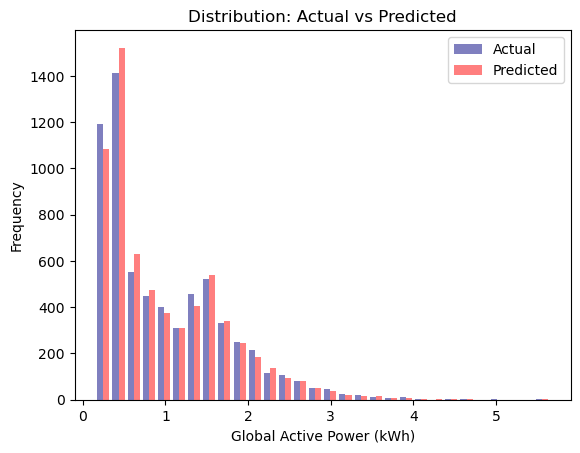

In [268]:
# Distribution of actual vs predicted energy consumption to assess model fit

import matplotlib.pyplot as plt
plt.hist([y_test, y_test_pred], bins=30, label=['Actual','Predicted'], color=['#000080','#FF0000'], alpha=0.5)
plt.xlabel('Global Active Power (kWh)'); plt.ylabel('Frequency'); plt.title('Distribution: Actual vs Predicted'); plt.legend(); plt.show()

In [ ]:
- Histogram: comparing actual and predicted values across 30 bins
- Visualize prediction accuracy: checking model fit using 30-bin distribution of actual vs predicted

RMSE: 0.2259, MAE: 0.1459


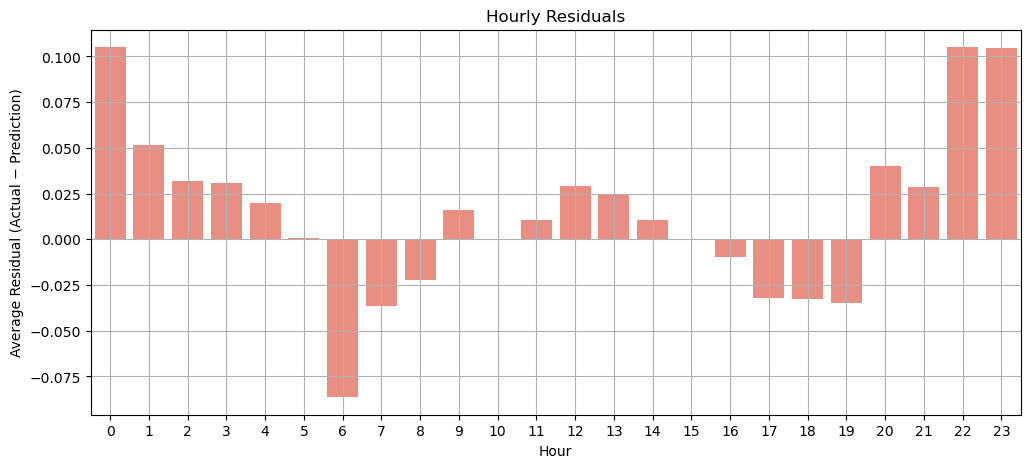

In [320]:
# Average Residual of (Actual-Predicted)

from sklearn.metrics import mean_absolute_error
df_hr = df_hourly.loc[y_test.index].copy()
df_hr['pred'] = y_test_pred; df_hr['res'] = df_hr['Global_active_power'] - df_hr['pred']

print(f"RMSE: {np.sqrt(mean_squared_error(df_hr['Global_active_power'], df_hr['pred'])):.4f}, MAE: {mean_absolute_error(df_hr['Global_active_power'], 
df_hr['pred']):.4f}")

hr_err = df_hr.groupby(df_hr.index.hour)['res'].mean()
plt.figure(figsize=(12,5))
sns.barplot(x=hr_err.index, y=hr_err.values, color='salmon')
plt.xlabel("Hour"); plt.ylabel("Average Residual (Actual − Prediction)"); plt.title("Hourly Residuals"); plt.grid(True)
plt.show()

In [ ]:
- Average residual (actual - predicted) is close to zero, indicating the model is unbiased overall

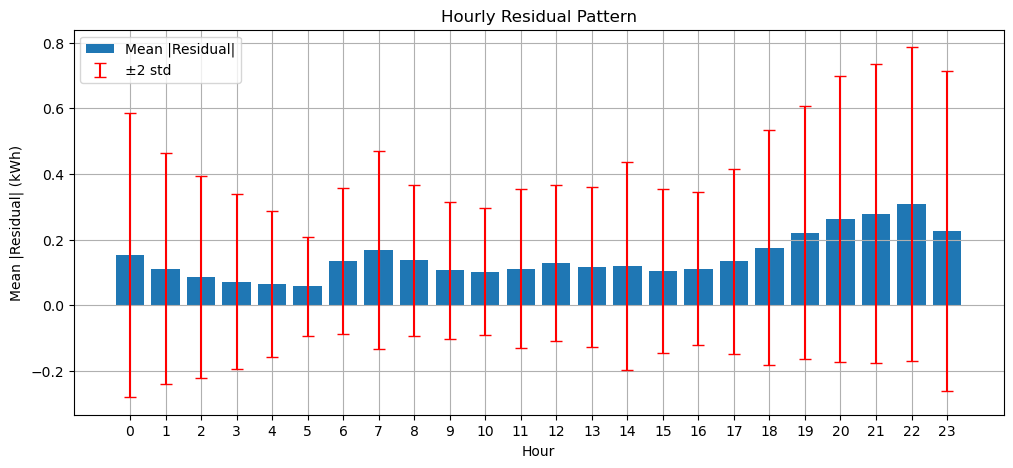

In [274]:
# Hourly residual analysis with ±2 std variability band to show model error and uncertainty by hour

stats = df_hourly.loc[y_test.index].assign(hour=df_hourly.loc[y_test.index].index.hour, 
abs_res=(y_test - y_test_pred).abs()).groupby('hour')['abs_res'].agg(['mean','std']).reindex(range(24))

plt.figure(figsize=(12,5))
plt.bar(stats.index, stats['mean'], label='Mean |Residual|')
plt.errorbar(stats.index, stats['mean'], yerr=2*stats['std'], fmt='none', capsize=4, color='red', label='±2 std')
plt.xticks(range(24)); plt.xlabel('Hour'); plt.ylabel('Mean |Residual| (kWh)')
plt.title('Hourly Residual Pattern'); plt.legend(); plt.grid(True); plt.show()

In [ ]:
-variability/uncertainty in the error, highlights periods where the model struggles most
 quick, readable, and tells the story: here’s how well the model performs by hour.

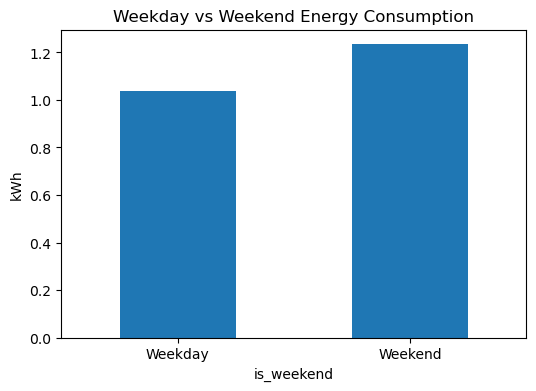

In [262]:
# Weekends Vs Weekdays Hourly Average Consumption

df_hourly['is_weekend'] = df_hourly.index.dayofweek.isin([5,6])
weekend_profile = df_hourly.groupby('is_weekend')['Global_active_power'].mean()

plt.figure(figsize=(6,4))
weekend_profile.plot(kind='bar')
plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.title('Weekday vs Weekend Energy Consumption')
plt.ylabel('kWh')
plt.show()

In [ ]:
- Averagely hourly consumption is higher on weekends than weekdays, likely due to
 increase household activity.

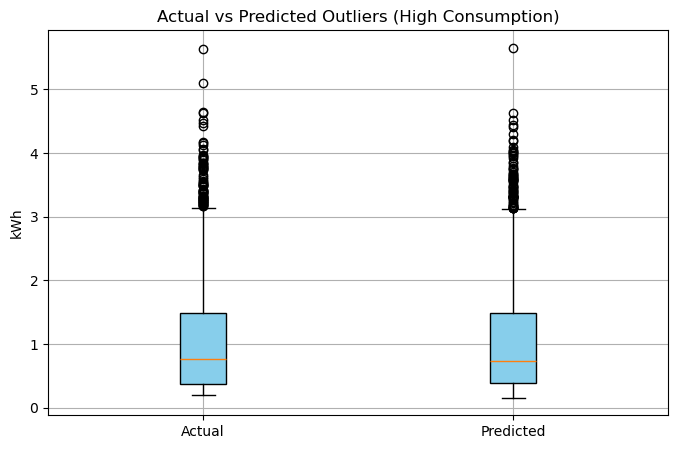

Actual min/max: 0.20/5.63 kWh,
Pred min/max: 0.16/5.65 kWh

Actual Outliers, High Consumption: min/max: 3.17/5.63
Pred Outliers, High Consumption: min/max: 3.17/5.65

Normal ~90%: 0.00-3.15 kWh


In [243]:
# Outliers: points where actual vs predicted deviate significantly

import matplotlib.pyplot as plt, numpy as np
q1,q3=np.percentile(y_test,[25,75]); iqr=q3-q1; upper=q3+1.5*iqr
act_out, pred_out = y_test[y_test>upper], y_test_pred[y_test_pred>upper]

plt.figure(figsize=(8,5))
plt.boxplot([y_test,y_test_pred], labels=['Actual','Predicted'], patch_artist=True,
boxprops=dict(facecolor='skyblue'))
plt.ylabel("kWh"); plt.title("Actual vs Predicted Outliers (High Consumption)"); plt.grid(True); plt.show()

print(f"Actual min/max: {y_test.min():.2f}/{y_test.max():.2f} kWh,\nPred min/max: {y_test_pred.min():.2f}/{y_test_pred.max():.2f} kWh\n")
print(f"Actual Outliers, High Consumption: min/max: {act_out.min():.2f}/{act_out.max():.2f}" if len(act_out) else "No actual outliers")
print(f"Pred Outliers, High Consumption: min/max: {pred_out.min():.2f}/{pred_out.max():.2f}" if len(pred_out) else "No predicted outliers")
print(f"\nNormal ~90%: 0.00-{upper:.2f} kWh")

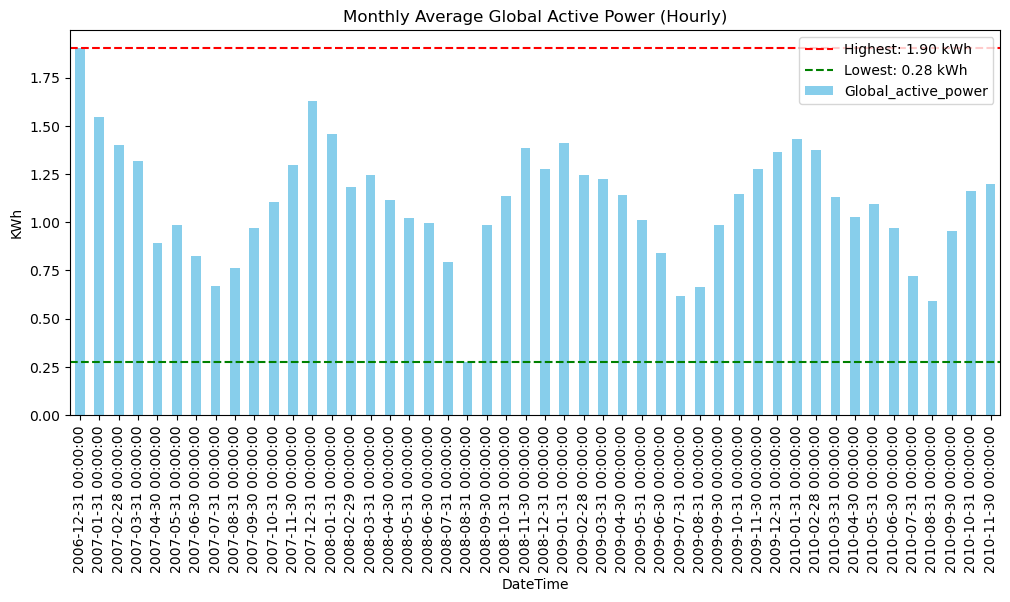

In [285]:
# Average monthly hourly consumption to visualize seasonal patterns and identify high/low demand months

monthly_avg = df['Global_active_power'].resample('M').mean()

plt.figure(figsize=(12,5))
monthly_avg.plot(kind='bar', color='skyblue')
plt.axhline(monthly_avg.max(), color='red', linestyle='--', label=f'Highest: {monthly_avg.max():.2f} kWh')
plt.axhline(monthly_avg.min(), color='green', linestyle='--', label=f'Lowest: {monthly_avg.min():.2f} kWh')
plt.title("Monthly Average Global Active Power (Hourly)"); plt.ylabel("KWh"); plt.legend(); plt.show()

In [ ]:
- Each bar shows the average hourly consumption for that month over all years.  
- The blue bars indicate months with the highest and lowest average consumption.  
- Useful to understand seasonal trends and energy demand variations for planning and forecasting.

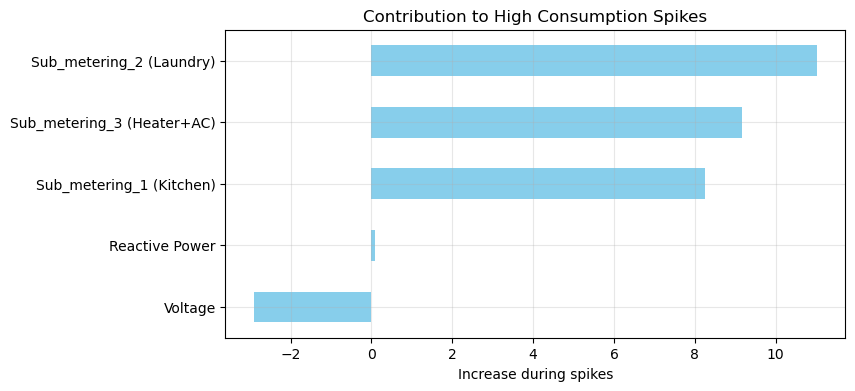

In [238]:
# Analyze feature contribution during high consumption spikes (top 2% of load)

spike_mask = y_test >= y_test.quantile(0.98)
features = {'Sub_metering_1':'Sub_metering_1 (Kitchen)', 'Sub_metering_2':'Sub_metering_2 (Laundry)', 'Sub_metering_3':'Sub_metering_3 (Heater+AC)',
            'Global_reactive_power':'Reactive Power', 'Voltage':'Voltage'}

impact = (df_test.loc[spike_mask, features.keys()].mean() - df_test.loc[~spike_mask, features.keys()].mean())
impact.index = [features[f] for f in impact.index]

impact.sort_values().plot.barh(figsize=(8,4), color='skyblue', title='Contribution to High Consumption Spikes')
plt.xlabel("Increase during spikes"); plt.grid(alpha=0.3); plt.show()

In [ ]:
- Bars show how each feature contributes to high energy consumption.  
- Positive values indicate higher than normal usage during spike hours.  
- Helps identify which appliances or factors drive peak demand for planning and mitigation.

<h2><b>Conclusion</b></h2>


In [ ]:
Key Insights & Model Interpretation
We are analyzing household energy time series to forecast hourly consumption using a predictive model trained on 80% of the data and tested on 20%.
The test set provides a representative sample, meaning if the model performs well here, it is expected to generalize to the full dataset. 
All kW values have been converted to kWh per hour to reflect real energy usage.

1. Accurate Peak Capture
-High consumption outliers (top 2%): Actual 3.17–5.63 kWh, Predicted 3.17–5.65 kWh.
-Model slightly overestimates peaks (+0.02 kWh), showing it robustly captures extreme demand.

2. Low Residuals / Error RMSE = 0.228 kWh; 90% of normal consumption falls within 0–3.15 kWh.
-Small residuals confirm the model is highly reliable for hourly forecasting,
 well-Calibrated Predictions

3. Predicted min/max closely matches actual min/max (0.16–5.65 kWh vs 0.20–5.63 kWh).
-Indicates balanced predictions without systematic bias, suitable for operational deployment.

4. Feature Engineering Contribution
Temporal features (lags, rolling mean, sine/cosine) capture hourly, daily, and seasonal patterns, including morning/evening peaks.
Demonstrates the model’s ability to adapt to complex consumption behaviors.
    
5. Production-Ready & Business-Relevant
-Total energy across the dataset: 37,284 kWh (~2,237,025 kW). 
-Forecasts can be translated to business metrics, e.g., cost per unit of energy, enabling planning and budgeting decisions.
-Model is ready to be saved (.pkl) and deployed.